<a href="https://colab.research.google.com/github/DKB-004/black-scholes-monte-carlo/blob/main/black_scholes%2C_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import os

In [3]:
def black_scholes(S,K,T,r,sigma,option_type='call'):

    # S=current stock price, K=strike price, T=time to expiry in years, r=risk-free rate,sigma=annualised volatility, option_type = str — 'call' or 'put'

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

In [4]:
# Test 1: At the money
call_atm = black_scholes(100, 100, 1.0, 0.05, 0.2, "call")
put_atm = black_scholes(100, 100, 1.0, 0.05, 0.2, "put")
print("ATM Call:", round(call_atm, 4), "| ATM Put:", round(put_atm, 4))

# Test 2: In the money
call_itm = black_scholes(110, 100, 1.0, 0.05, 0.2, "call")
put_itm = black_scholes(110, 100, 1.0, 0.05, 0.2, "put")
print("ITM Call:", round(call_itm, 4), "| ITM Put:", round(put_itm, 4))

# Test 3: Out of money
call_otm = black_scholes(90, 100, 1.0, 0.05, 0.2, "call")
put_otm = black_scholes(90, 100, 1.0, 0.05, 0.2, "put")
print("OTM Call:", round(call_otm, 4), "| OTM Put:", round(put_otm, 4))

ATM Call: 10.4506 | ATM Put: 5.5735
ITM Call: 17.663 | ITM Put: 2.7859
OTM Call: 5.0912 | OTM Put: 10.2142


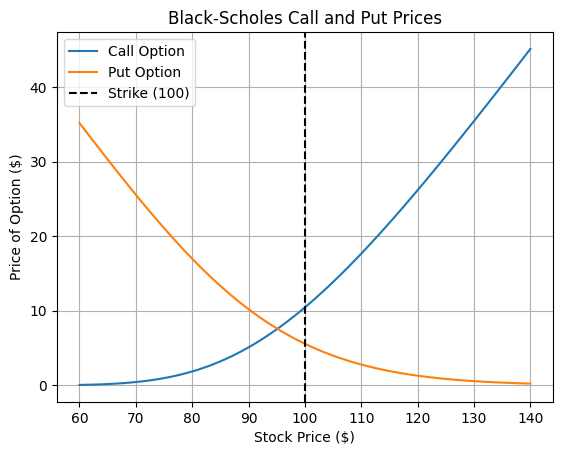

In [5]:

stock_prices = []
call_prices = []
put_prices = []

for s in range(60, 141):
    stock_prices.append(s)
    c = black_scholes(s, 100, 1.0, 0.05, 0.2, "call")
    p = black_scholes(s, 100, 1.0, 0.05, 0.2, "put")

    call_prices.append(c)
    put_prices.append(p)

plt.plot(stock_prices, call_prices, label="Call Option")
plt.plot(stock_prices, put_prices, label="Put Option")

plt.axvline(x=100, color="black", linestyle="--", label="Strike (100)")

plt.xlabel("Stock Price ($)")
plt.ylabel("Price of Option ($)")
plt.title("Black-Scholes Call and Put Prices")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def monte_carlo_pricer(S,K,T,r,sigma, n=100_000,option_type='call'):

    Z   = np.random.standard_normal(n)
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option_type == 'call':
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)

    price     = np.exp(-r * T) * np.mean(payoffs)
    std_error = np.std(payoffs) / np.sqrt(n)

    return price, std_error

Monte Carlo  : $10.3755 +/- 0.0487
Black-Scholes: $10.4506
Difference   : $0.0751


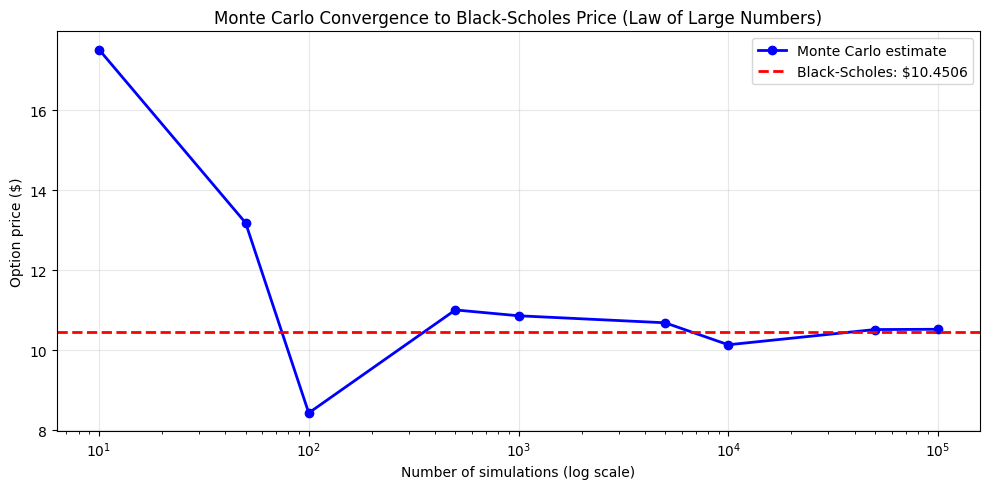

Plot 2 saved.


In [ ]:
mc_price, mc_err = monte_carlo_pricer(100, 100, 1.0, 0.05, 0.2)
bs_price         = black_scholes(100, 100, 1.0, 0.05, 0.2)

print(f"Monte Carlo  : ${mc_price:.4f} +/- {mc_err:.4f}")
print(f"Black-Scholes: ${bs_price:.4f}")
print(f"Difference   : ${abs(mc_price - bs_price):.4f}")

# Plot 2, Monte Carlo convergence (Law of Large Numbers)
n_values  = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = [monte_carlo_pricer(100, 100, 1.0, 0.05, 0.2, n)[0] for n in n_values]

plt.figure(figsize=(10, 5))
plt.semilogx(n_values, mc_prices, marker='o', label='Monte Carlo estimate', color='blue', linewidth=2)
plt.axhline(y=bs_price, color='red', linestyle='--', linewidth=2, label=f'Black-Scholes: ${bs_price:.4f}')
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Option price ($)")
plt.title("Monte Carlo Convergence to Black-Scholes Price (Law of Large Numbers)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
print("Plot 2 saved.")

In [11]:
def greeks(S,K,T,r,sigma):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
             - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    vega  = S * norm.pdf(d1) * np.sqrt(T) * 0.01

    return {'Delta': delta, 'Gamma': gamma, 'Theta': theta, 'Vega': vega}


Delta : 0.636831
Gamma : 0.018762
Theta : -0.017573
Vega  : 0.375240


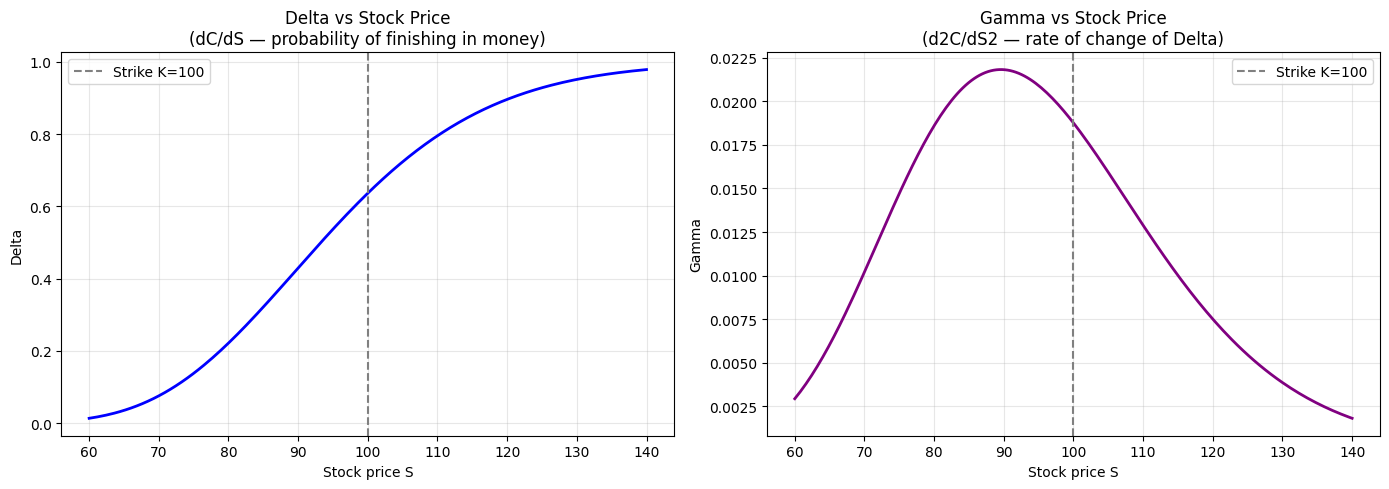

In [12]:
g = greeks(S=100, K=100, T=1.0, r=0.05, sigma=0.2)
for name, val in g.items():
    print(f"{name:6s}: {val:.6f}")


S_range = np.linspace(60, 140, 200)
deltas  = [greeks(S, 100, 1.0, 0.05, 0.2)['Delta'] for S in S_range]
gammas  = [greeks(S, 100, 1.0, 0.05, 0.2)['Gamma'] for S in S_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(S_range, deltas, color='blue', linewidth=2)
axes[0].axvline(x=100, linestyle='--', color='gray', label='Strike K=100')
axes[0].set_title("Delta vs Stock Price\n(dC/dS — probability of finishing in money)")
axes[0].set_xlabel("Stock price S")
axes[0].set_ylabel("Delta")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(S_range, gammas, color='purple', linewidth=2)
axes[1].axvline(x=100, linestyle='--', color='gray', label='Strike K=100')
axes[1].set_title("Gamma vs Stock Price\n(d2C/dS2 — rate of change of Delta)")
axes[1].set_xlabel("Stock price S")
axes[1].set_ylabel("Gamma")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


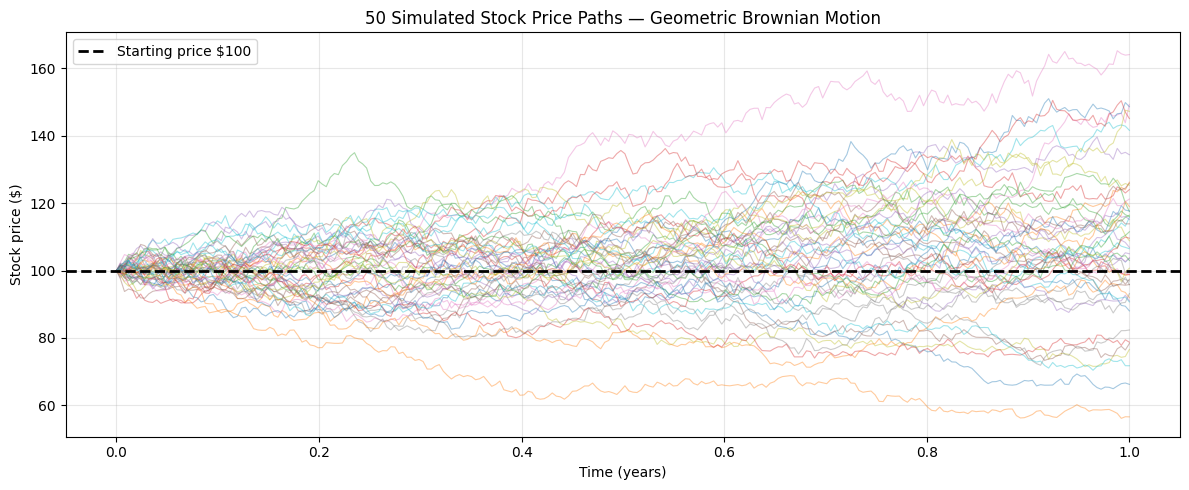

In [9]:
n_paths = 50
n_steps = 252
dt      = 1.0 / n_steps
t       = np.linspace(0, 1.0, n_steps)

plt.figure(figsize=(12, 5))
for _ in range(n_paths):
    S      = np.zeros(n_steps)
    S[0]   = 100
    for step in range(1, n_steps):
        Z       = np.random.standard_normal()
        S[step] = S[step-1] * np.exp((0.05 - 0.5 * 0.04) * dt + 0.2 * np.sqrt(dt) * Z)
    plt.plot(t, S, alpha=0.4, linewidth=0.8)

plt.axhline(y=100, color='black', linestyle='--', linewidth=2, label='Starting price $100')
plt.xlabel("Time (years)")
plt.ylabel("Stock price ($)")
plt.title("50 Simulated Stock Price Paths — Geometric Brownian Motion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
reliance = yf.download("RELIANCE.NS",start="2025-01-01",end="2026-01-01")

reliance['Returns'] = reliance['Close'].pct_change()

daily_vol = reliance['Returns'].std()
annual_vol = daily_vol * np.sqrt(252)

current_price = reliance['Close'].iloc[-1]

print(f"Reliance current price : ₹{float(current_price):.2f}")
print(f"Daily volatility       : {float(daily_vol)*100:.4f}%")
print(f"Annual volatility      : {float(annual_vol)*100:.4f}%")

/tmp/ipykernel_2043/2777266265.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance = yf.download("RELIANCE.NS",start="2025-01-01",end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Reliance current price : ₹1570.40
Daily volatility       : 1.2314%
Annual volatility      : 19.5477%



/tmp/ipykernel_2043/2777266265.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Reliance current price : ₹{float(current_price):.2f}")


In [15]:
S     = float(current_price)   # real market price
K     = round(S * 1.05)        # strike price 5% above current (out of the money)
T     = 0.25                   # 3 months to expiry
r     = 0.0625                  # India risk-free rate (RBI repo rate ~6.25%)
sigma = float(annual_vol)      # real historical volatility from market data

call = black_scholes(S,K,T,r,sigma,'call')
put  = black_scholes(S,K,T,r,sigma,'put')

print(f"Reliance Industries Option Pricing")
print(f"===================================")
print(f"Stock price (S)     : Rs.{S:.2f}")
print(f"Strike price (K)    : Rs.{K:.2f}")
print(f"Time to expiry      : {T} years (3 months)")
print(f"Risk-free rate      : {r*100}% (RBI repo rate)")
print(f"Historical vol      : {sigma*100:.4f}%")
print(f"-----------------------------------")
print(f"Call option price   : Rs.{call:.2f}")
print(f"Put option price    : Rs.{put:.2f}")

# Greeks for Reliance
g = greeks(S,K,T,r,sigma)
print(f"-----------------------------------")
for name, val in g.items():
    print(f"{name:6s}          : {val:.6f}")

Reliance Industries Option Pricing
Stock price (S)     : Rs.1570.40
Strike price (K)    : Rs.1649.00
Time to expiry      : 0.25 years (3 months)
Risk-free rate      : 6.25% (RBI repo rate)
Historical vol      : 19.5477%
-----------------------------------
Call option price   : Rs.39.28
Put option price    : Rs.92.32
-----------------------------------
Delta           : 0.385544
Gamma           : 0.002491
Theta           : -0.418566
Vega            : 3.002673


/tmp/ipykernel_2043/225220429.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S     = float(current_price)   # real market price


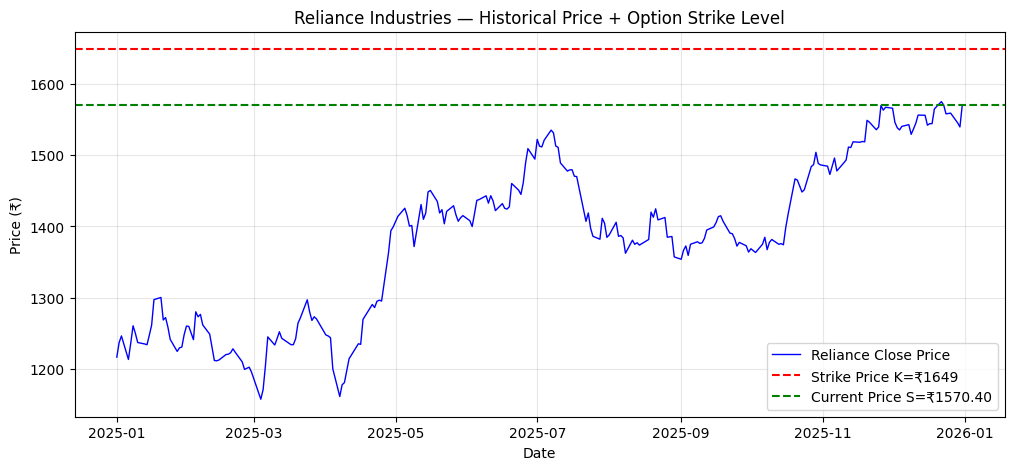

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(reliance.index, reliance['Close'], color='blue', linewidth=1, label='Reliance Close Price')
plt.axhline(y=K, color='red', linestyle='--', linewidth=1.5, label=f'Strike Price K=₹{K}')
plt.axhline(y=S, color='green', linestyle='--', linewidth=1.5, label=f'Current Price S=₹{S:.2f}')
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.title("Reliance Industries — Historical Price + Option Strike Level")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
